# Structure factors: what a diffraction experiment sees

X-ray and neutron diffraction do not measure a density. They measure its Fourier
coefficients, one per reflection, and the crystallographer's name for one of those is the
**structure factor**

$$ F(\mathbf H) \;=\; \int_\Omega \rho(\mathbf r)\, e^{i\mathbf H \cdot \mathbf r}\, d^3r ,
\qquad
F_j(\mathbf H) \;=\; \int_\Omega m_j(\mathbf r)\, e^{i\mathbf H \cdot \mathbf r}\, d^3r $$

for every reciprocal lattice vector $\mathbf H$ inside a cutoff. The first is what an X-ray
sees, because X-rays scatter off charge; the second is what a neutron sees, because
neutrons scatter off magnetization. $F(0)$ is the number of electrons in the cell and
$F_j(0)$ is its magnetic moment, so the two are anchored on numbers you already know.

A calculation with pseudopotentials carries **valence electrons only**, and the core is
where most of the X-ray scattering comes from. So this is the *valence* structure factor,
and the honest thing is not to hide that but to say which reflections it can be believed
on. There is one class where it is not merely believable but exact in principle: a
**forbidden reflection**, where the spherical part of every atom cancels by symmetry and
what is left is the bonding charge between the atoms.

| | |
|---|---|
| silicon, all its electrons (all-electron reference) | $F(000) = 28$ |
| silicon, valence only (here) | $F(000) = 8$ |
| the (111) reflection, core-dominated | 1.75 here against 15.14 |
| **the forbidden (222), pure bonding charge** | **0.3474 here against 0.3342** |
| a superposition of spherical atoms at (222) | $0$, to machine precision |

In [1]:
from pathlib import Path

from pypresso import Calculator

PSEUDO, CASES = Path("../tests/data/pseudo"), Path("../tests/data/qe")

silicon = Calculator.from_file(CASES / "si-sfac.in", PSEUDO, announce=False)
factors = silicon.get_structure_factors(hmax=5.0)

print(factors.table(limit=10))

     h     k     l  mult         |H|          Re F          Im F           |F|
------------------------------------------------------------------------------
     0     0     0     1    0.000000      8.000000      0.000000      8.000000
     1    -1    -1     4    1.066941      1.237107     -1.237107      1.749533
     1     1    -1     4    1.066941      1.237107      1.237107      1.749533
     0     0    -2     6    1.231997      0.000000      0.000000      0.000000
     2     0    -2    12    1.742307     -0.080710     -0.000000      0.080710
     1    -1    -3    12    2.043036     -0.250196     -0.250196      0.353831
     1     1    -3    12    2.043036     -0.250196      0.250196      0.353831
     2    -2    -2     4    2.133882      0.000000     -0.347406      0.347406
     2     2    -2     4    2.133882     -0.000000      0.347406      0.347406
     0     0    -4     6    2.463994     -0.391424     -0.000000      0.391424


## Reflections that are not allowed to be there

Silicon is diamond structure, and its space group has a glide plane. That forbids whole
families of reflections outright: $(h00)$ is absent unless $h$ is a multiple of four, so
$(200)$ and $(420)$ have to vanish **exactly**, whatever the density does inside the cell.
They come out at $10^{-16}$ electrons below.

$(222)$ is different, and it is the interesting one. The space group allows it. What
forbids it is an assumption about the *atoms*: if each atom's charge were spherical, the
two atoms in the cell would contribute equal and opposite amplitudes and cancel. So the
measured intensity of the (222) reflection is a direct picture of how far silicon's atoms
are from spherical, which is to say of the bond charge sitting between them. It was
measured for exactly that reason, and it is small: about a third of an electron against
the eight in the cell.

In [2]:
for label in [(1, -1, -1), (0, 0, -2), (2, -2, -2), (2, 0, -4)]:
    print(f"{label}   |F| = {abs(factors.of(label)):.6f}")

(1, -1, -1)   |F| = 1.749533
(0, 0, -2)   |F| = 0.000000
(2, -2, -2)   |F| = 0.347406
(2, 0, -4)   |F| = 0.000000


## The valence density against all of it

The comparison below is against an all-electron calculation of the same crystal, and the
two are *not* expected to agree: one carries 28 electrons per atom pair and the other 8.
What the figure shows is where that stops mattering. Every allowed reflection is an order
of magnitude apart, because the core dominates it. The forbidden (222) is not, because the
core is spherical and cancels out of it exactly, leaving both codes measuring the same
bonding charge.

In [3]:
import matplotlib.pyplot as plt
import numpy as np

reference = {}
for line in (Path("../tests/data/elk") / "si-sfac.elk.out").read_text().splitlines():
    fields = line.split()
    if len(fields) == 8 and fields[0].lstrip("-").isdigit():
        key = tuple(sorted(abs(int(v)) for v in fields[:3]))
        reference.setdefault(key, (float(fields[4]), float(fields[7])))

ours = {tuple(sorted(abs(int(round(v))) for v in factors.vectors.indices[row])):
        (factors.vectors.length[row], abs(factors.charge[row]))
        for row in range(len(factors))}
shared = [k for k in ours if k in reference and sum(k)]
h = np.array([ours[k][0] for k in shared])
mine = np.array([max(ours[k][1], 1e-6) for k in shared])
theirs = np.array([max(reference[k][1], 1e-6) for k in shared])

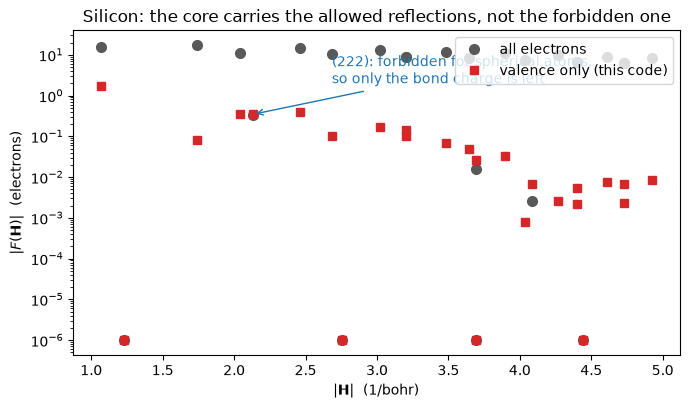

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.semilogy(h, theirs, "o", ms=7, color="0.35", label="all electrons")
ax.semilogy(h, mine, "s", ms=6, color="tab:red", label="valence only (this code)")
star = shared.index((2, 2, 2))
ax.annotate("(222): forbidden for spherical atoms,\nso only the bond charge is left",
            xy=(h[star], mine[star]), xytext=(h[star] + 0.55, 2.0),
            arrowprops=dict(arrowstyle="->", color="tab:blue"), color="tab:blue")
ax.set_xlabel(r"$|\mathbf{H}|$  (1/bohr)")
ax.set_ylabel(r"$|F(\mathbf{H})|$  (electrons)")
ax.set_title("Silicon: the core carries the allowed reflections, not the forbidden one")
ax.legend(loc="upper right")
fig.tight_layout()

## Neutrons see something X-rays cannot

An antiferromagnet has two sublattices whose moments point opposite ways. Chemically they
are the same atom, so the charge density repeats with **half** the magnetic period, and the
reflections split into two disjoint sets: the ones an X-ray sees and the ones a neutron
sees. The magnetic ones are the *superlattice* reflections, and finding them is how
antiferromagnetic order was discovered.

The chain below is the cheapest crystal that does this: two hydrogen atoms in a cell, with
opposite moments. Along the chain, the odd reflections carry magnetization and no charge,
and the even ones carry charge and no magnetization. The zeros are exact, not small:
the operation that halves the charge's period is a symmetry of the crystal as long as it is
combined with flipping every spin.

In [5]:
chain = Calculator.from_file(CASES / "h-chain-afm.in", PSEUDO, announce=False)
neutron = chain.get_structure_factors(hmax=2.0, transform=None, reduce=False)

rows = {int(m[2]): row for row, m in enumerate(np.asarray(neutron.vectors.miller))
        if m[0] == 0 and m[1] == 0 and m[2] >= 0}
print(f"{'l':>4}{'X-ray |F|':>14}{'neutron |F|':>14}")
for l, row in sorted(rows.items()):
    print(f"{l:>4}{abs(neutron.charge[row]):>14.6f}"
          f"{abs(neutron.magnetization[row, 0]):>14.6f}")

   l     X-ray |F|   neutron |F|
   0      2.000000      0.000001
   1      0.000000      1.228716
   2      0.859083      0.000000
   3      0.000000      0.387129


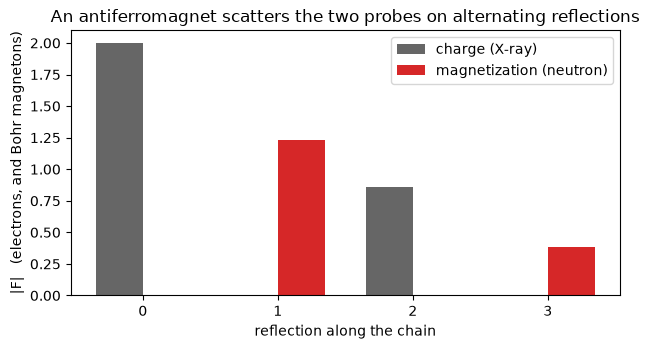

In [6]:
fig, ax = plt.subplots(figsize=(6.4, 3.6))
ell = np.array(sorted(rows))
width = 0.35
ax.bar(ell - width / 2, [abs(neutron.charge[rows[l]]) for l in ell], width,
       color="0.4", label="charge (X-ray)")
ax.bar(ell + width / 2, [abs(neutron.magnetization[rows[l], 0]) for l in ell], width,
       color="tab:red", label="magnetization (neutron)")
ax.set_xlabel("reflection along the chain")
ax.set_ylabel("|F|   (electrons, and Bohr magnetons)")
ax.set_title("An antiferromagnet scatters the two probes on alternating reflections")
ax.set_xticks(ell)
ax.legend()
fig.tight_layout()

## What to trust, and how far out

Three statements, in the order they stop being safe:

* **Forbidden reflections are the strong suit.** The core cancels, so what is left is the
  aspherical valence density, which is what a pseudopotential is built to get right.
  Silicon's (222) lands within 4% of an all-electron calculation of the same crystal.
* **Allowed charge reflections are core-dominated** and a valence density simply does not
  have that information. Quote them as valence structure factors or add the core back.
* **Magnetic reflections are good at small $|\mathbf H|$ and degrade outwards.** For
  ferromagnetic iron the normalized magnetic form factor is within 6% of an all-electron
  value at the first reflection and drifts to tens of percent by $|\mathbf H| \approx 3$
  per bohr, because iron's moment sits in the 3d shell, close enough to the nucleus that a
  pseudopotential smooths it. Raising the plane-wave cutoff by half changes that by less
  than 0.1%, so it is the atom's description and not the basis.

Norm-conserving, ultrasoft and PAW datasets all work, and they are not equally good at
this. An ultrasoft or PAW calculation puts back a charge inside each atomic sphere that a
norm-conserving one leaves out, and that shows up here as a factor of two: measured against
an all-electron calculation of the same crystal restricted to its valence states, silicon's
(111) reflection comes out 0.7% low for both soft datasets against 1.5% for the
norm-conserving one. It buys nothing at all on the forbidden (222), whose asphericity is of
a shape none of these datasets carries.

An energy window is also available, which rebuilds the density from a chosen range of
states before transforming it. That is what turns a structure factor from a measurement of
the whole charge into a probe of a particular set of bonding states.

The checks behind these numbers are in `tests/regression/test_structure_factors.py`,
including the one that says the (222) is bonding charge and nothing else: a superposition
of free atoms gives zero there to machine precision.